# Explicabilidade — SHAP | Regressão Logística (modelo vencedor)

Modelo: `logistic_regression_baseline_tuned` (C=10, L2, class_weight=balanced)  
Dataset de referência: **baseline** (sem balanceamento, X_test = 2024)

Plots produzidos:
1. **Summary bar** — importância global das features (média |SHAP|)
2. **Beeswarm** — distribuição do impacto por feature e por paciente
3. **Waterfall** — explicação individual: óbito corretamente identificado e óbito não detectado
4. **Dependence plot** — relação entre a feature mais importante e o SHAP value

In [23]:
import os
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

shap.initjs()

BASE_DIR   = '../../data/features/baseline'
MODEL_PATH = '../../output/modelos/logistic_regression_baseline_tuned.joblib'
OUTPUT_PLOTS = '../../output/plots'

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Carregamento do modelo e dados

In [24]:
pipeline = joblib.load(MODEL_PATH)

X_test = pd.read_parquet(os.path.join(BASE_DIR, 'X_test.parquet'))
y_test = pd.read_parquet(os.path.join(BASE_DIR, 'y_test.parquet')).squeeze()
X_train = pd.read_parquet(os.path.join(BASE_DIR, 'X_train.parquet'))

# remover coluna de split (não entra no modelo)
YEAR_COL = 'ANO_IS'
X_test_prep  = X_test.drop(columns=[YEAR_COL], errors='ignore').copy()
X_train_prep = X_train.drop(columns=[YEAR_COL], errors='ignore').copy()

# corrigir outlier de idade
for df in [X_test_prep, X_train_prep]:
    if 'age_years' in df.columns:
        df.loc[df['age_years'] > 120, 'age_years'] = np.nan

# alinhar com y_test sem NaN
mask_valid = y_test.notna()
X_test_valid = X_test_prep[mask_valid.values]
y_test_valid = y_test[mask_valid]

print(f'X_test_valid: {X_test_valid.shape}')
print(f'Óbitos no teste: {int(y_test_valid.sum()):,} ({y_test_valid.mean()*100:.2f}%)')

X_test_valid: (160534, 52)
Óbitos no teste: 5,295 (3.30%)


## 2. Pré-processamento e nomes das features

In [25]:
preprocessor = pipeline['pre']
clf          = pipeline['clf']

# matriz transformada (numpy) para o SHAP
X_test_transformed  = preprocessor.transform(X_test_valid)
X_train_transformed = preprocessor.transform(X_train_prep)

feature_names = list(preprocessor.get_feature_names_out())

# wrapper em DataFrame para facilitar os plots
X_test_df  = pd.DataFrame(X_test_transformed,  columns=feature_names)
X_train_df = pd.DataFrame(X_train_transformed, columns=feature_names)

print(f'Features após pré-processamento: {len(feature_names)}')
print(feature_names)

Features após pré-processamento: 60
['ALRM_HIPOT', 'ALRM_PLAQ', 'ALRM_VOM', 'ALRM_SANG', 'ALRM_HEMAT', 'ALRM_ABDOM', 'ALRM_LETAR', 'ALRM_HEPAT', 'ALRM_LIQ', 'GRAV_PULSO', 'GRAV_CONV', 'GRAV_ENCH', 'GRAV_INSUF', 'GRAV_TAQUI', 'GRAV_EXTRE', 'GRAV_HIPOT', 'GRAV_HEMAT', 'GRAV_MELEN', 'GRAV_METRO', 'GRAV_SANG', 'GRAV_AST', 'GRAV_MIOC', 'GRAV_CONSC', 'GRAV_ORGAO', 'FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA', 'VOMITO', 'NAUSEA', 'DOR_COSTAS', 'CONJUNTVIT', 'ARTRITE', 'ARTRALGIA', 'PETEQUIA_N', 'LEUCOPENIA', 'LACO', 'DOR_RETRO', 'DIABETES', 'HEMATOLOG', 'HEPATOPAT', 'RENAL', 'HIPERTENSA', 'AUTO_IMUNE', 'age_years', 'epi_week', 'CS_SEXO', 'CS_ESCOL_N', 'CS_RACA_1.0', 'CS_RACA_2.0', 'CS_RACA_3.0', 'CS_RACA_4.0', 'CS_RACA_5.0', 'CS_GESTANT_1.0', 'CS_GESTANT_2.0', 'CS_GESTANT_3.0', 'CS_GESTANT_4.0', 'CS_GESTANT_5.0', 'CS_GESTANT_6.0', 'SG_UF']


## 3. SHAP LinearExplainer

`LinearExplainer` usa os coeficientes do modelo para calcular valores SHAP exatos,  
sem aproximação. É o explainer recomendado para modelos lineares.

In [26]:
explainer = shap.LinearExplainer(clf, X_train_df)

# amostra do teste para visualizações globais (mais rápido que calcular 160k)
N_SAMPLE = 3000
idx_sample = np.random.choice(len(X_test_df), size=N_SAMPLE, replace=False)
X_sample = X_test_df.iloc[idx_sample]
y_sample = y_test_valid.values[idx_sample]

shap_values_sample = explainer(X_sample)

print(f'SHAP values calculados para {N_SAMPLE} pacientes amostrados.')
print(f'Shape: {shap_values_sample.values.shape}')

SHAP values calculados para 3000 pacientes amostrados.
Shape: (3000, 60)


## 4. Summary bar — importância global das features

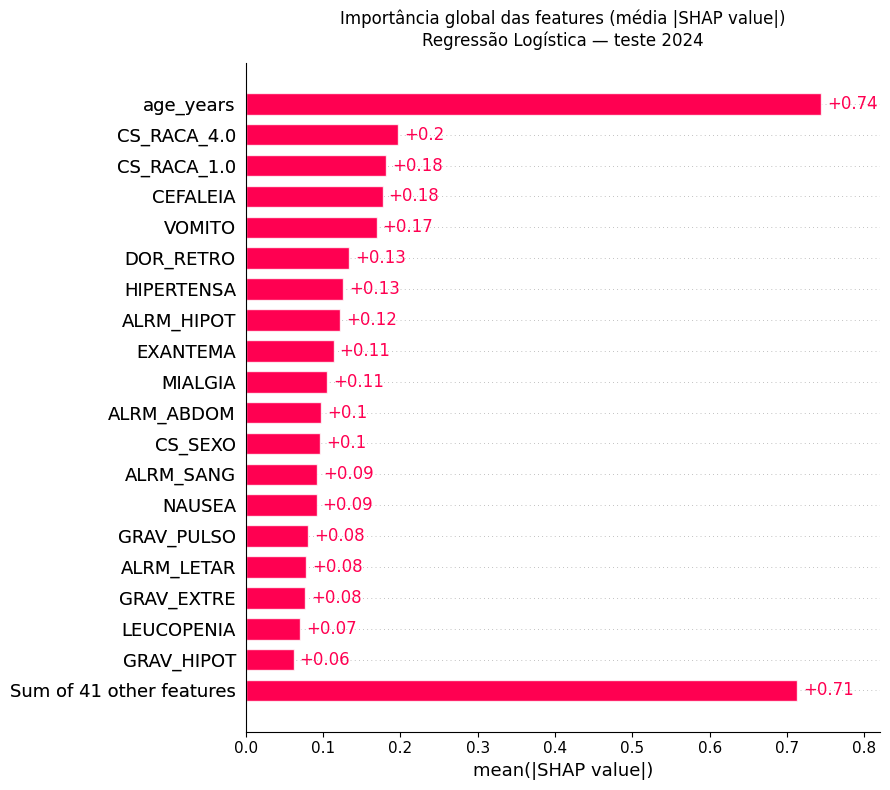

Salvo: output/plots/shap_summary_bar.png


In [27]:
fig, ax = plt.subplots(figsize=(9, 8))
shap.plots.bar(shap_values_sample, max_display=20, show=False, ax=ax)
ax.set_title('Importância global das features (média |SHAP value|)\nRegressão Logística — teste 2024', pad=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOTS, 'shap_summary_bar.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: output/plots/shap_summary_bar.png')

## 5. Beeswarm — distribuição do impacto por paciente

Cada ponto é um paciente. Cor = valor da feature (vermelho = alto, azul = baixo).  
Posição horizontal = impacto no risco predito (SHAP value).

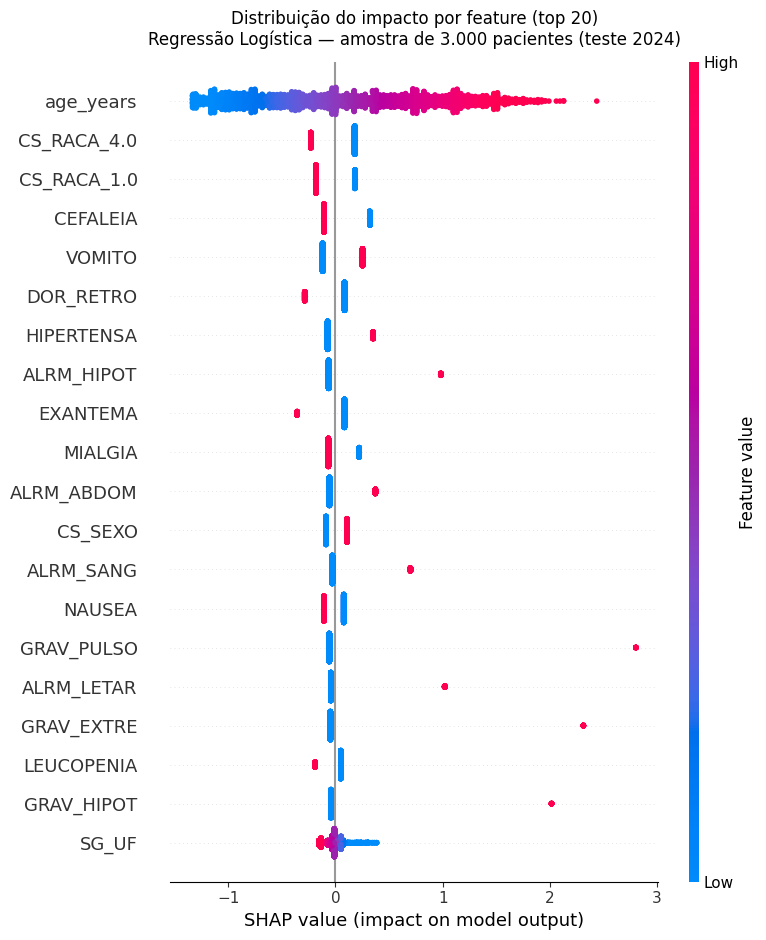

Salvo: output/plots/shap_beeswarm.png


In [28]:
mean_abs_shap = np.abs(shap_values_sample.values).mean(axis=0)
top20_names = [feature_names[i] for i in np.argsort(mean_abs_shap)[-20:][::-1]]
shap_values_top20 = shap_values_sample[:, top20_names]

plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values_top20, max_display=20, show=False)
plt.title('Distribuição do impacto por feature (top 20)\nRegressão Logística — amostra de 3.000 pacientes (teste 2024)', pad=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOTS, 'shap_beeswarm.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: output/plots/shap_beeswarm.png')

## 6. Waterfall plots — explicação individual

Dois casos contrastantes:
- **Caso A:** óbito **corretamente identificado** (alto risco, y=1, proba alta)
- **Caso B:** óbito **não detectado** (alto risco esperado, y=1, proba baixa — falso negativo)

In [29]:
# calcular probas para todos os casos da amostra
probas_sample = clf.predict_proba(X_sample)[:, 1]

obitos_mask = y_sample == 1
idx_obitos  = np.where(obitos_mask)[0]

# Caso A: óbito com maior probabilidade predita
idx_caso_a = idx_obitos[np.argmax(probas_sample[idx_obitos])]

# Caso B: óbito com menor probabilidade predita (pior FN)
idx_caso_b = idx_obitos[np.argmin(probas_sample[idx_obitos])]

print(f'Caso A — óbito detectado:   idx={idx_caso_a}, proba={probas_sample[idx_caso_a]:.4f}')
print(f'Caso B — óbito não detectado: idx={idx_caso_b}, proba={probas_sample[idx_caso_b]:.4f}')

Caso A — óbito detectado:   idx=1531, proba=1.0000
Caso B — óbito não detectado: idx=2731, proba=0.0590


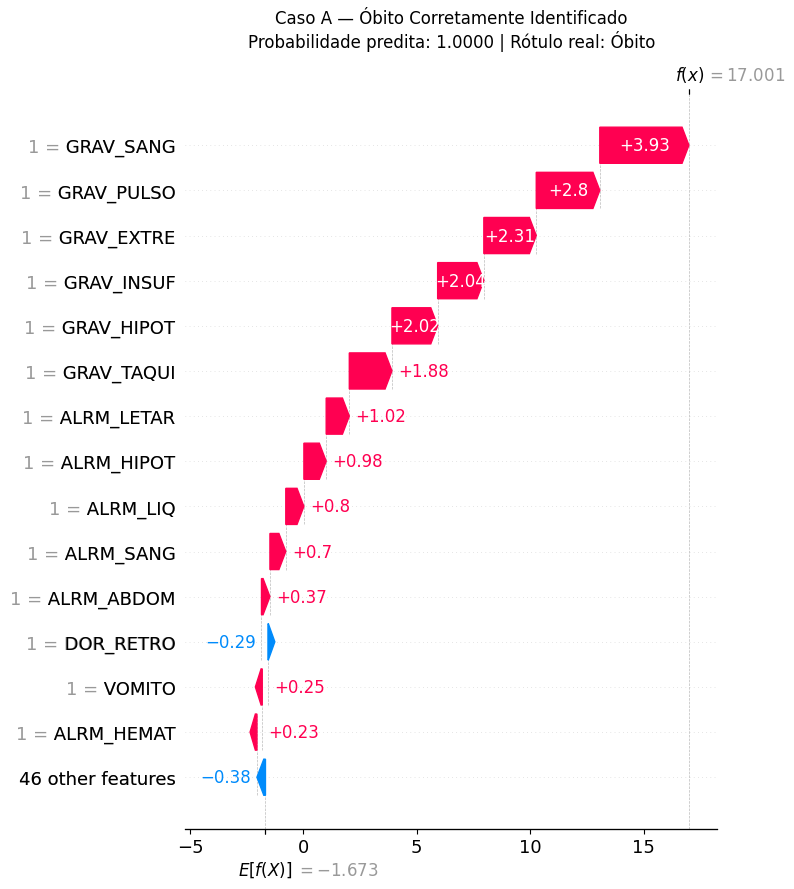

Salvo: output/plots/shap_waterfall_obito_detectado.png


In [30]:
# Waterfall — Caso A (óbito detectado)
plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_values_sample[idx_caso_a], max_display=15, show=False)
plt.title(
    f'Caso A — Óbito Corretamente Identificado\n'
    f'Probabilidade predita: {probas_sample[idx_caso_a]:.4f} | Rótulo real: Óbito',
    pad=12
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOTS, 'shap_waterfall_obito_detectado.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: output/plots/shap_waterfall_obito_detectado.png')

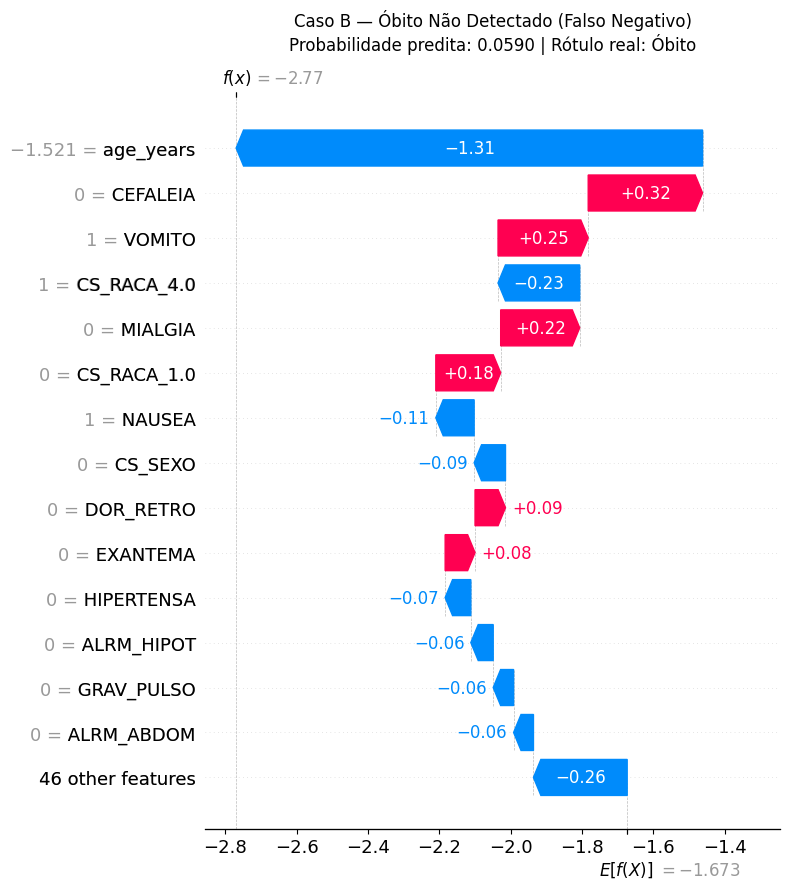

Salvo: output/plots/shap_waterfall_falso_negativo.png


In [31]:
# Waterfall — Caso B (falso negativo: óbito não detectado)
plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_values_sample[idx_caso_b], max_display=15, show=False)
plt.title(
    f'Caso B — Óbito Não Detectado (Falso Negativo)\n'
    f'Probabilidade predita: {probas_sample[idx_caso_b]:.4f} | Rótulo real: Óbito',
    pad=12
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOTS, 'shap_waterfall_falso_negativo.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: output/plots/shap_waterfall_falso_negativo.png')

## 7. Dependence plot — feature mais importante

Mostra como o valor da feature mais importante varia com o SHAP value,  
colorido pela feature de maior interação automática detectada pelo SHAP.

Feature mais importante:  age_years (mean |SHAP| = 0.7438)
Feature de interação:     CS_RACA_4.0


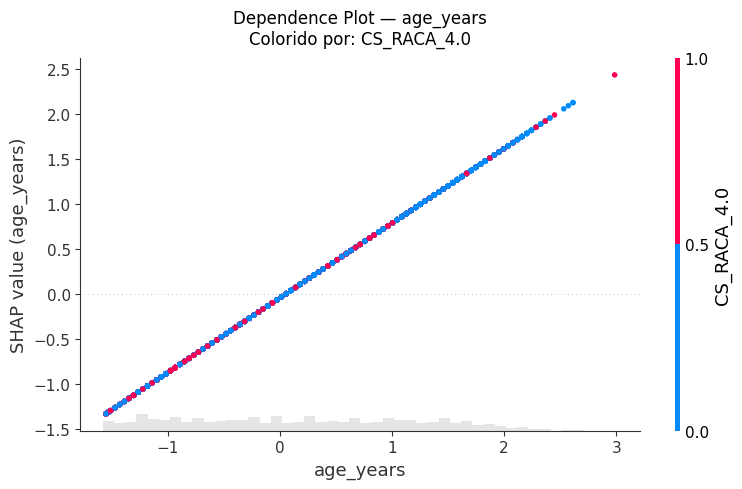

Salvo: output/plots/shap_dependence_top_feature.png


In [32]:
# identificar a feature mais importante (maior média |SHAP|)
mean_abs_shap = np.abs(shap_values_sample.values).mean(axis=0)
top_feature_idx  = int(np.argmax(mean_abs_shap))
top_feature_name = feature_names[top_feature_idx]
second_feature_idx  = int(np.argsort(mean_abs_shap)[-2])
second_feature_name = feature_names[second_feature_idx]

print(f'Feature mais importante:  {top_feature_name} (mean |SHAP| = {mean_abs_shap[top_feature_idx]:.4f})')
print(f'Feature de interação:     {second_feature_name}')

fig, ax = plt.subplots(figsize=(8, 5))
shap.plots.scatter(
    shap_values_sample[:, top_feature_name],
    color=shap_values_sample[:, second_feature_name],
    ax=ax,
    show=False
)
ax.set_title(
    f'Dependence Plot — {top_feature_name}\n'
    f'Colorido por: {second_feature_name}',
    pad=10
)
ax.set_xlabel(top_feature_name)
ax.set_ylabel(f'SHAP value ({top_feature_name})')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLOTS, 'shap_dependence_top_feature.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo: output/plots/shap_dependence_top_feature.png')

## 8. Ranking completo das features por importância SHAP

In [33]:
df_shap_importancia = pd.DataFrame({
    'feature':    feature_names,
    'mean_abs_shap': mean_abs_shap,
    'coeficiente': clf.coef_[0],
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

df_shap_importancia['rank'] = df_shap_importancia.index + 1
df_shap_importancia['direcao'] = df_shap_importancia['coeficiente'].apply(
    lambda c: 'aumenta risco' if c > 0 else 'reduz risco'
)

print('Top 20 features por importância SHAP:')
display(df_shap_importancia[['rank', 'feature', 'mean_abs_shap', 'coeficiente', 'direcao']].head(20))

df_shap_importancia.to_csv('../../output/metricas/shap_feature_importance.csv', index=False)
print('\nTabela completa salva: output/metricas/shap_feature_importance.csv')

Top 20 features por importância SHAP:


,rank,feature,mean_abs_shap,coeficiente,direcao
0,1,age_years,0.743835,0.830885,aumenta risco
1,2,CS_RACA_4.0,0.197168,-0.408757,reduz risco
2,3,CS_RACA_1.0,0.181825,-0.363649,reduz risco
3,4,CEFALEIA,0.177112,-0.427463,reduz risco
4,5,VOMITO,0.169262,0.371711,aumenta risco
5,6,DOR_RETRO,0.134154,-0.371205,reduz risco
6,7,HIPERTENSA,0.126144,0.423246,aumenta risco
7,8,ALRM_HIPOT,0.122309,1.046208,aumenta risco
8,9,EXANTEMA,0.113868,-0.441006,reduz risco
9,10,MIALGIA,0.105363,-0.287674,reduz risco



Tabela completa salva: output/metricas/shap_feature_importance.csv
